In [ ]:
#menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/Kuliah/Semester 7/Machine Learning/Praktikum/praktikum mandiri/praktikum mandiri 11/data"

In [ ]:
!pip install contextily rasterio pyproj

In [ ]:
 # Import Library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import geopandas as gpd
import contextily as ctx

In [ ]:
# Baca Dataset
df = pd.read_csv("/content/drive/MyDrive/Kuliah/Semester 7/Machine Learning/Praktikum/praktikum mandiri/praktikum mandiri 11/data/uber-raw-data-apr14.csv")
df

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512
...,...,...,...,...
564511,4/30/2014 23:22:00,40.7640,-73.9744,B02764
564512,4/30/2014 23:26:00,40.7629,-73.9672,B02764
564513,4/30/2014 23:31:00,40.7443,-73.9889,B02764
564514,4/30/2014 23:32:00,40.6756,-73.9405,B02764


In [ ]:
# 1. Cleaning Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB


In [ ]:
df.isnull().sum()

,0
Date/Time,0
Lat,0
Lon,0
Base,0


In [ ]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

In [ ]:
# 2. Visualisasi Heatmap GPS
heat_data = df[['Lat', 'Lon']].dropna().values.tolist()

m = folium.Map([40.75, -73.98], zoom_start=11)
HeatMap(heat_data[:10000]).add_to(m)  # 10 ribu titik agar tidak terlalu berat
m

In [ ]:
# 3. Visualisasi Peta Titik Pickup

In [ ]:
# Konversi ke GeoDataFrame:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Lon'], df['Lat']),
    crs="EPSG:4326"
)

In [ ]:
# Ubah ke Web Mercator
gdf_web = gdf.to_crs(epsg=3857)

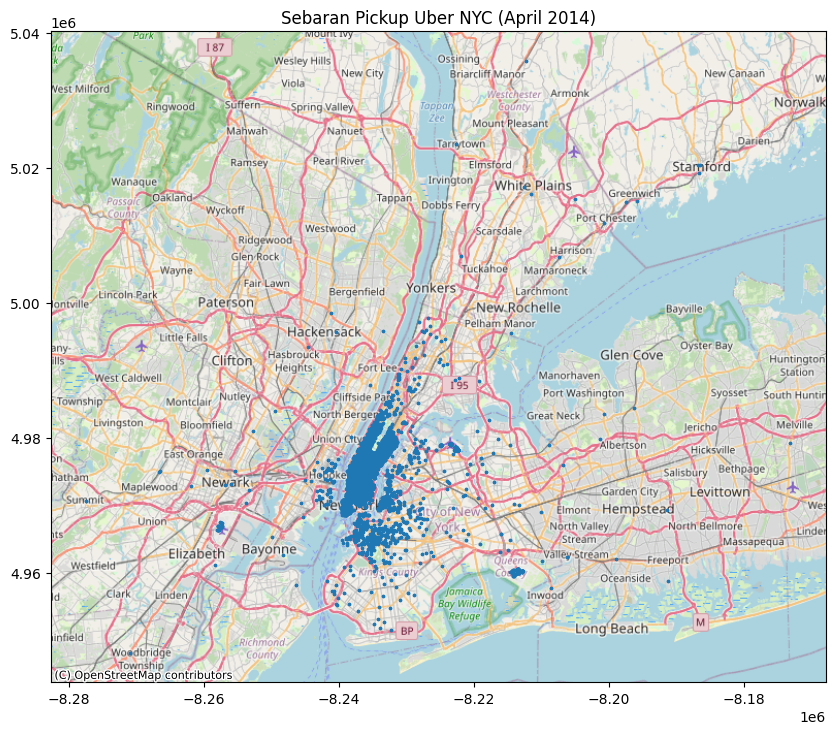

In [ ]:
# Plot:
fig, ax = plt.subplots(figsize=(10, 10))
gdf_web.sample(5000).plot(ax=ax, markersize=3)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.title("Sebaran Pickup Uber NYC (April 2014)")
plt.show()

In [ ]:
# 4. Normalisasi Data untuk DBSCAN
coords = df[['Lat', 'Lon']]
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

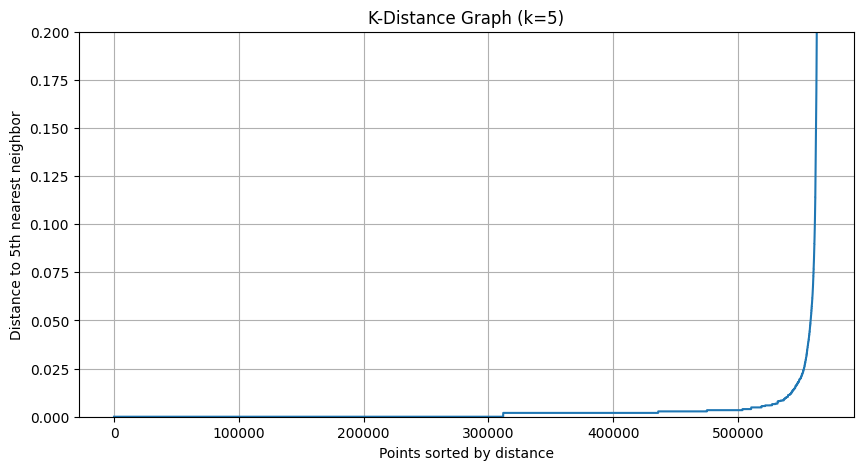

In [ ]:
# 5. Menentukan ε (eps) dengan K-Distance Graph

from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(coords_scaled)
distances, indices = neighbors_fit.kneighbors(coords_scaled)

# Ambil jarak ke tetangga ke-5
k_dist = np.sort(distances[:, 4])

# Plot versi zoom agar elbow terlihat
plt.figure(figsize=(10,5))
plt.plot(k_dist)
plt.title("K-Distance Graph (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 5th nearest neighbor")
plt.ylim(0, 0.2)
plt.grid(True)
plt.show()

In [ ]:
# 6. Jalankan DBSCAN
db = DBSCAN(eps=0.03, min_samples=5).fit(coords_scaled)
df['cluster'] = db.labels_
df['cluster'].value_counts()

,count
cluster,
0,453171
5,56814
3,11239
9,10683
-1,8592
...,...
704,4
686,4
658,3


In [ ]:
# 7. Analisis Hasil Cluster & Noise

In [ ]:
# Noise selalu memiliki label -1.
cluster_counts = df['cluster'].value_counts()
cluster_counts

,count
cluster,
0,453171
5,56814
3,11239
9,10683
-1,8592
...,...
704,4
686,4
658,3


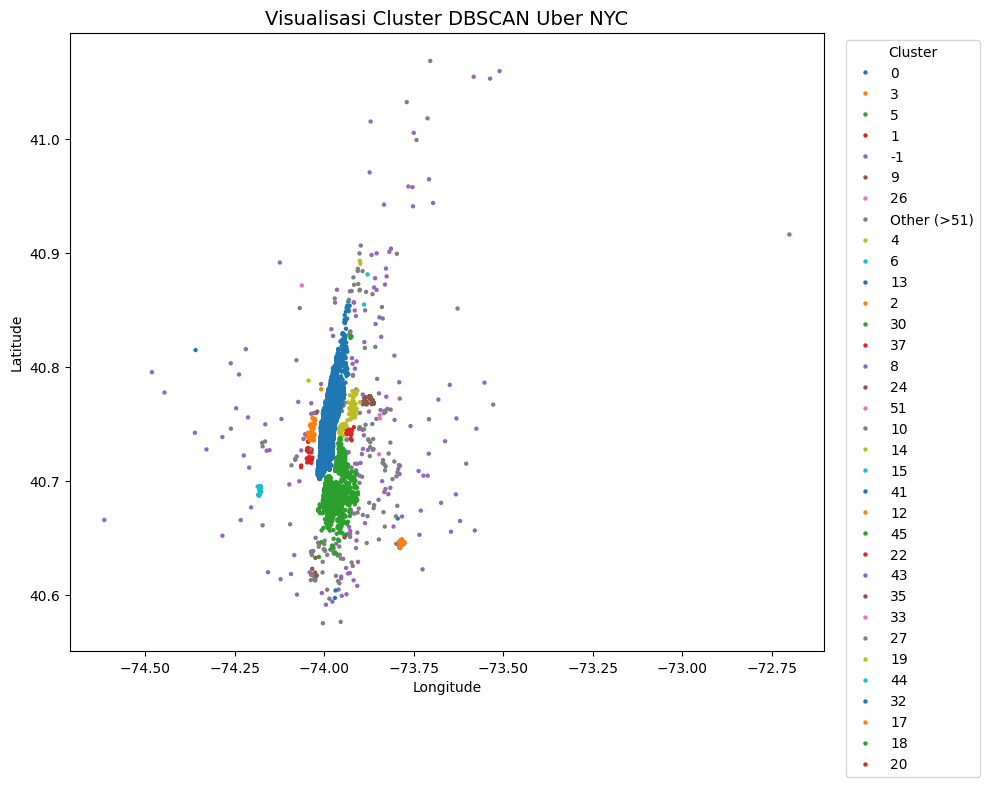

In [60]:
# Visualisasi sebaran cluster:

plt.figure(figsize=(10, 8))

# ambil sampel biar ringan
sample_df = df.sample(10000, random_state=42).copy()

# bikin kolom tampilan cluster agar legend tidak panjang
sample_df['cluster_view'] = sample_df['cluster'].astype(str)

# cluster yang bukan -1 sampai 51 → diganti label lain
mask_other = ~sample_df['cluster'].isin(range(-1, 52))
sample_df.loc[mask_other, 'cluster_view'] = 'Other (>51)'

ax = sns.scatterplot(
    data=sample_df,
    x='Lon',
    y='Lat',
    hue='cluster_view',
    palette='tab10',
    s=10,
    linewidth=0
)

plt.title("Visualisasi Cluster DBSCAN Uber NYC", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# legend pindah ke kanan
ax.legend(
    title='Cluster',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


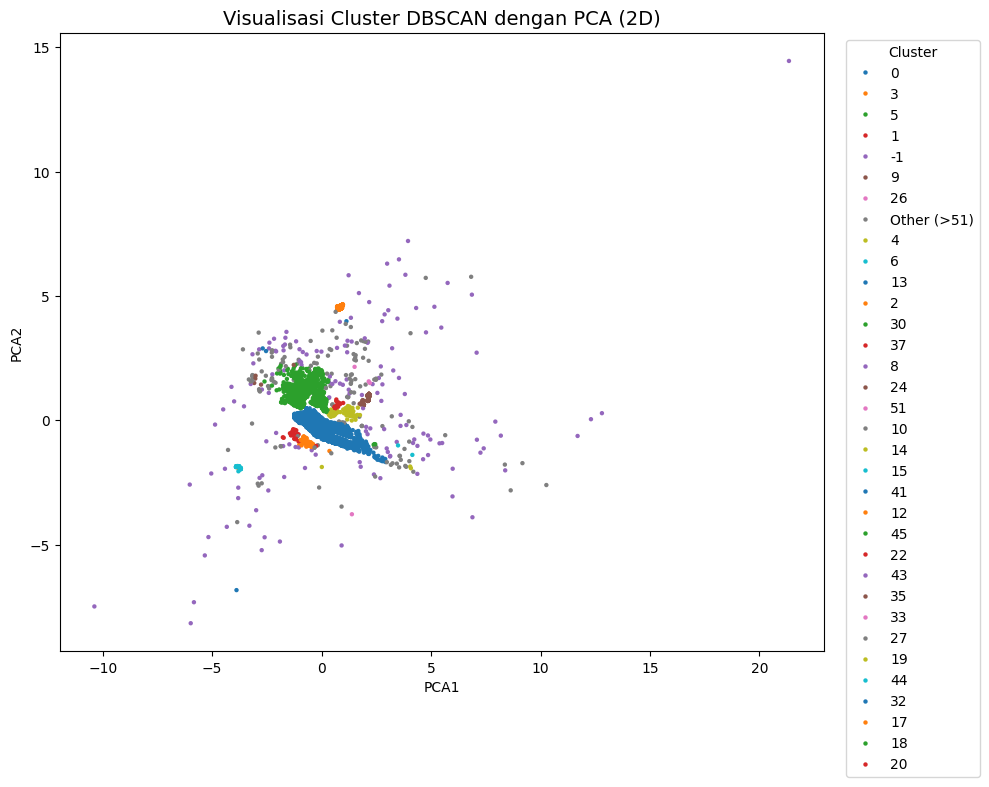

In [61]:
# 8. Visualisasi Cluster dengan PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(coords_scaled)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

# ambil sampel supaya plot tidak berat
sample_df = df.sample(10000, random_state=42).copy()

# buat kolom untuk legend yang dirapikan
sample_df['cluster_view'] = sample_df['cluster'].astype(str)

# cluster -1 sampai 51 ditampilkan apa adanya, sisanya digabung
mask_other = ~sample_df['cluster'].isin(range(-1, 52))
sample_df.loc[mask_other, 'cluster_view'] = 'Other (>51)'

plt.figure(figsize=(10, 8))

ax = sns.scatterplot(
    data=sample_df,
    x='PCA1',
    y='PCA2',
    hue='cluster_view',
    palette='tab10',
    s=10,
    linewidth=0
)

plt.title("Visualisasi Cluster DBSCAN dengan PCA (2D)", fontsize=14)
plt.xlabel("PCA1")
plt.ylabel("PCA2")

# legend di sebelah kanan
ax.legend(
    title='Cluster',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

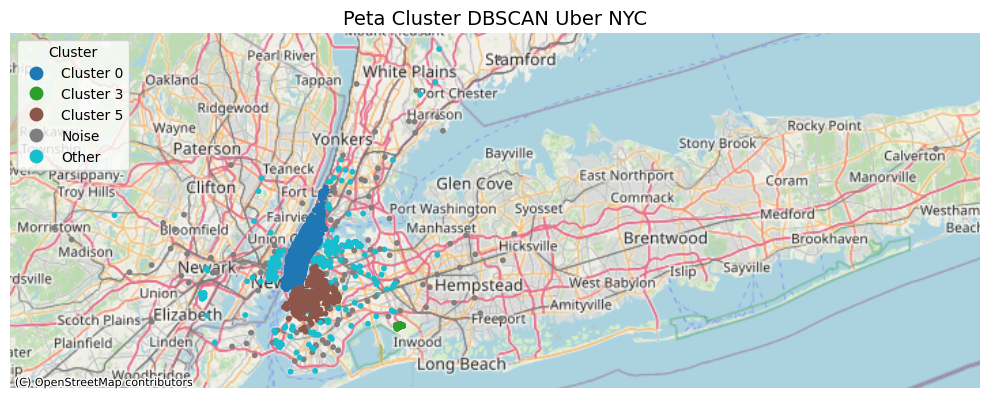

In [65]:
# 9. Visualisasi DBSCAN di Peta
cluster_counts = df['cluster'].value_counts()

# buang noise (-1) dulu untuk milih cluster besar
non_noise = cluster_counts[cluster_counts.index != -1]
top_k = 3                                 # mau tampilkan 3 cluster terbesar
top_clusters = list(non_noise.head(top_k).index)

# buat salinan data untuk peta
sample_map = df.sample(7000, random_state=42).copy()

def label_cluster(c):
    if c == -1:
        return 'Noise'
    elif c in top_clusters:
        return f'Cluster {c}'
    else:
        return 'Other'

sample_map['cluster_cat'] = sample_map['cluster'].apply(label_cluster)

# ---- jadikan GeoDataFrame ----
gdf_cluster = gpd.GeoDataFrame(
    sample_map,
    geometry=gpd.points_from_xy(sample_map['Lon'], sample_map['Lat']),
    crs="EPSG:4326"
).to_crs(3857)

# ---- plot ----
fig, ax = plt.subplots(figsize=(10, 8))

gdf_cluster.plot(
    ax=ax,
    column='cluster_cat',    # kategori: Cluster X, Other, Noise
    markersize=10,
    cmap='tab10',
    legend=True,
    legend_kwds={'title': 'Cluster'}
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.title("Peta Cluster DBSCAN Uber NYC", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()